# MSML606 HW-3

### AI tools (ChatGPT, Claude) were used for general understanding and clarification of programming concepts and report organization.

## Part I: Programming

## Problem 1. Implement Randomized Quicksort and Heapsort



In [14]:
import random
import time
import tracemalloc
import sys
import matplotlib.pyplot as plt

In [15]:
def randomized_partition(arr, low, high):
    # choose random pivot and move it to the end
    random_index = random.randint(low, high)
    arr[random_index], arr[high] = arr[high], arr[random_index]

    pivot = arr[high]
    i = low - 1

    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]

    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1


def randomized_quicksort(arr, low, high):
    if low < high:
        pivot_index = randomized_partition(arr, low, high)
        randomized_quicksort(arr, low, pivot_index - 1)
        randomized_quicksort(arr, pivot_index + 1, high)


def quicksort_sort(arr):
    temp = arr[:]
    if len(temp) > 0:
        randomized_quicksort(temp, 0, len(temp) - 1)
    return temp



In [16]:
def heapify(arr, n, i):
    largest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left

    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)


def heapsort(arr):
    temp = arr[:]
    n = len(temp)

    # build max heap
    for i in range(n // 2 - 1, -1, -1):
        heapify(temp, n, i)

    # move largest element to end one by one
    for i in range(n - 1, 0, -1):
        temp[0], temp[i] = temp[i], temp[0]
        heapify(temp, i, 0)

    return temp



## Problem 2. Test Cases


In [17]:
def generate_input(case_type, n):
    arr = []

    if case_type == "random":
        for _ in range(n):
            arr.append(random.uniform(-1000, 1000))

    elif case_type == "repeated":
        possible_values = [1.1, 2.2, 3.3, 4.4, 5.5]
        for _ in range(n):
            arr.append(random.choice(possible_values))

    elif case_type == "sorted":
        for i in range(n):
            arr.append(float(i))

    elif case_type == "reverse":
        for i in range(n, 0, -1):
            arr.append(float(i))

    return arr


def is_sorted(arr):
    for i in range(len(arr) - 1):
        if arr[i] > arr[i + 1]:
            return False
    return True


def run_test_cases():
    case_types = ["random", "repeated", "sorted", "reverse"]
    n = 20

    print("Running test cases for both algorithms...\n")

    for case_type in case_types:
        arr = generate_input(case_type, n)

        quick_result = quicksort_sort(arr)
        heap_result = heapsort(arr)

        print("Case:", case_type)
        print("Original:", arr)
        print("Randomized Quicksort output:", quick_result)
        print("Heapsort output:", heap_result)
        print("Quicksort correct:", is_sorted(quick_result))
        print("Heapsort correct:", is_sorted(heap_result))
        print()


## Problem 3. Performance Analysis

In [18]:
def measure_algorithm(sort_function, arr):
    tracemalloc.start()
    start = time.perf_counter()

    output = None
    error_message = None

    try:
        output = sort_function(arr)
    except RecursionError:
        error_message = "RecursionError"
    except Exception as e:
        error_message = str(e)

    end = time.perf_counter()
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "sorted_output": output,
        "time_seconds": end - start,
        "peak_memory_bytes": peak_mem,
        "error": error_message
    }


def print_single_result(algorithm_name, case_type, n, result):
    correct = False
    if result["sorted_output"] is not None:
        correct = is_sorted(result["sorted_output"])

    print("Algorithm:", algorithm_name)
    print("Input Type:", case_type)
    print("N:", n)
    print("Time (seconds):", result["time_seconds"])
    print("Peak Memory (bytes):", result["peak_memory_bytes"])
    print("Error:", result["error"])
    print("Correct:", correct)
    print()


def run_performance_analysis():
    sizes = [10**3, 10**4, 5 * 10**4, 10**5]
    case_types = ["random", "repeated", "sorted", "reverse"]

    all_results = []

    for case_type in case_types:
        print("========================================")
        print("Testing input type:", case_type)
        print("========================================\n")

        quick_times = []
        heap_times = []

        quick_memory = []
        heap_memory = []

        for n in sizes:
            arr = generate_input(case_type, n)

            quick_result = measure_algorithm(quicksort_sort, arr)
            heap_result = measure_algorithm(heapsort, arr)

            print_single_result("Randomized Quicksort", case_type, n, quick_result)
            print_single_result("Heapsort", case_type, n, heap_result)

            quick_times.append(quick_result["time_seconds"])
            heap_times.append(heap_result["time_seconds"])

            quick_memory.append(quick_result["peak_memory_bytes"])
            heap_memory.append(heap_result["peak_memory_bytes"])

            quick_correct = False
            heap_correct = False

            if quick_result["sorted_output"] is not None:
                quick_correct = is_sorted(quick_result["sorted_output"])

            if heap_result["sorted_output"] is not None:
                heap_correct = is_sorted(heap_result["sorted_output"])

            all_results.append({
                "algorithm": "Randomized Quicksort",
                "input_type": case_type,
                "n": n,
                "time_seconds": quick_result["time_seconds"],
                "peak_memory_bytes": quick_result["peak_memory_bytes"],
                "error": quick_result["error"],
                "correct": quick_correct
            })

            all_results.append({
                "algorithm": "Heapsort",
                "input_type": case_type,
                "n": n,
                "time_seconds": heap_result["time_seconds"],
                "peak_memory_bytes": heap_result["peak_memory_bytes"],
                "error": heap_result["error"],
                "correct": heap_correct
            })

        # running time plot
        plt.figure(figsize=(7, 5))
        plt.plot(sizes, quick_times, marker='o', label='Randomized Quicksort')
        plt.plot(sizes, heap_times, marker='s', label='Heapsort')
        plt.xlabel("Input Size N")
        plt.ylabel("Running Time (seconds)")
        plt.title("Running Time vs Input Size (" + case_type + ")")
        plt.legend()
        plt.grid(True)
        plt.show()

        # memory usage plot
        plt.figure(figsize=(7, 5))
        plt.plot(sizes, quick_memory, marker='o', label='Randomized Quicksort')
        plt.plot(sizes, heap_memory, marker='s', label='Heapsort')
        plt.xlabel("Input Size N")
        plt.ylabel("Peak Memory (bytes)")
        plt.title("Peak Memory vs Input Size (" + case_type + ")")
        plt.legend()
        plt.grid(True)
        plt.show()

    return all_results


def print_summary_table(results):
    print("\n================ FINAL SUMMARY ================\n")

    for row in results:
        print("Algorithm:", row["algorithm"],
              "| Input:", row["input_type"],
              "| N:", row["n"],
              "| Time:", row["time_seconds"],
              "| Peak Memory:", row["peak_memory_bytes"],
              "| Error:", row["error"],
              "| Correct:", row["correct"])


Sample input: [5.4, 2.1, 9.8, 1.0, 3.3, 7.7]
Randomized Quicksort result: [1.0, 2.1, 3.3, 5.4, 7.7, 9.8]
Heapsort result: [1.0, 2.1, 3.3, 5.4, 7.7, 9.8]

Running test cases for both algorithms...

Case: random
Original: [-436.72648516417985, -394.54529495345776, -45.21905604359347, 333.92913538664834, -743.2210401107857, -967.6878801281852, 185.25230861672708, 646.373626553456, -191.935040926772, -951.3715450801712, 887.5932703079575, 407.4062383832984, 245.0273872787834, 447.82554706324777, 587.5769844612619, -736.8416500916078, 623.4641718538717, 125.52485206893789, -811.8903575326692, -7.897328690198492]
Randomized Quicksort output: [-967.6878801281852, -951.3715450801712, -811.8903575326692, -743.2210401107857, -736.8416500916078, -436.72648516417985, -394.54529495345776, -191.935040926772, -45.21905604359347, -7.897328690198492, 125.52485206893789, 185.25230861672708, 245.0273872787834, 333.92913538664834, 407.4062383832984, 447.82554706324777, 587.5769844612619, 623.4641718538717

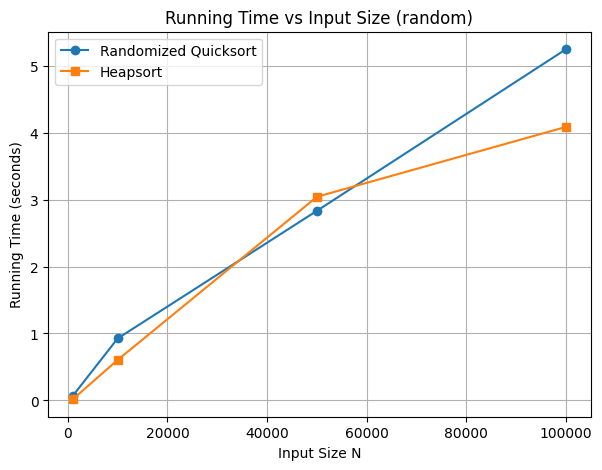

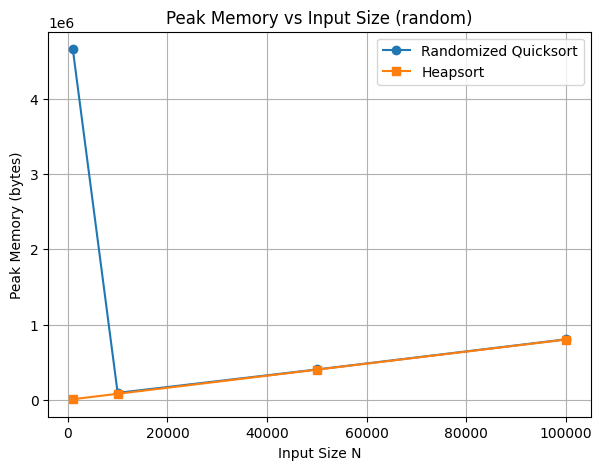

Testing input type: repeated

Algorithm: Randomized Quicksort
Input Type: repeated
N: 1000
Time (seconds): 0.34059634799996275
Peak Memory (bytes): 22659
Error: None
Correct: True

Algorithm: Heapsort
Input Type: repeated
N: 1000
Time (seconds): 0.01566358699983539
Peak Memory (bytes): 8324
Error: None
Correct: True

Algorithm: Randomized Quicksort
Input Type: repeated
N: 10000
Time (seconds): 169.41758207799967
Peak Memory (bytes): 209372
Error: None
Correct: True

Algorithm: Heapsort
Input Type: repeated
N: 10000
Time (seconds): 0.3462418429999161
Peak Memory (bytes): 80580
Error: None
Correct: True



In [ ]:
# increase recursion limit for large quicksort inputs
import sys
sys.setrecursionlimit(100000)


# Problem 1 demonstration
sample = [5.4, 2.1, 9.8, 1.0, 3.3, 7.7]

print("Sample input:", sample)
print("Randomized Quicksort result:", quicksort_sort(sample))
print("Heapsort result:", heapsort(sample))
print()


# Problem 2 test cases
run_test_cases()


# Problem 3 performance analysis
results = run_performance_analysis()

print_summary_table(results)